# Notebook 6 — Imaging phase: does the covariance source matter at high `p`?

**The question.** In low dimensions (notebook 4, `p=2`) the choice of noise-covariance *source* — the subject
**data** vs the **leave-one-out (LOO)** perturbations — made no measurable difference. The prediction was that
it *would* matter for real image patches, where `p` is large and voxels are strongly correlated. This notebook
takes that question to real OASIS patches, for linear **and** non-linear statistics.

**Honest stance.** This is an empirical privacy/utility harness, **not** a differential-privacy verifier.
Membership advantage (defined below) is a *lower bound* on leakage — an attack proves leakage, a failed attack
proves nothing. No DP guarantees are claimed, and Baseline A (the supervisor's reference mechanism) is left
frozen — we only measure it.

**Read start to finish.** The Background below defines the four ideas the results rest on. Then four **gates**
that must hold before any high-`p` number is trustworthy, the **covariance-source** result itself, a
mass-univariate **inference** check, and an oracle **validation**. Each section: one question, one figure, one
read-off.

*Prerequisites: notebooks 4 (covariance source, membership game) and 5 (inference).*

## Background — what carries over from notebooks 4–5, and what's new

This notebook assumes you've worked through notebooks 4 (covariance source + membership game) and 5
(inference). One-line recaps of what carries over, then the genuinely new pieces.

**Recaps (notebook 4).**
- **Membership advantage** — an attacker guesses whether a target was in the released data; advantage = TPR − FPR
  on a 0 = safe → 1 = fully exposed scale, and a *lower bound* on leakage.
- **Covariance source** — the correlated noise takes its correlation from the **data** (`Cov(subjects)`) or the
  **LOO** perturbations; magnitudes are matched, so only the correlation differs. `direct_loo` uses the raw LOO
  covariance without rescaling.
- **Fallback** — the mechanism only accepts a noise draw that dominates every subject's influence at every
  voxel; when it can't, it falls back to independent noise. The **fallback rate** is how often that happens.

**New here (imaging at high `p`).**
- **Patches and `p`.** We privatize small aligned cubes of voxels — a `4×4×4` patch is `p = 64` values. "High
  `p`" means these are far bigger than the `p=2` case of notebook 4, and because brain maps are smooth the
  voxels in a patch are strongly correlated.
- **The four gates.** Before trusting any high-`p` number we check four things: the attacker has more trials
  than dimensions (Gate 1), mass-univariate inference is multiple-comparisons corrected (Gate 2), we understand
  the rank/fallback behaviour (Gate 3), and every run is screened for degeneracy (Gate 4).

Of the recaps, **fallback** is the one to hold onto — it turns out to be the central high-`p` phenomenon.

## Setup and data

`make_source` returns an OASIS patch source when `nilearn` is available, else a spatially-correlated synthetic
stand-in so the notebook runs anywhere (flip `USE_OASIS = True` in your environment). `patch_power` expresses
the noise level as a fraction of the patch's own signal variance, so noise is comparable across datasets and
patch sizes — an absolute noise level would over-noise real OASIS values into meaningless ~zero advantage.

In [1]:
import sys, os, numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy.stats import t as tdist, norm
for cand in [".", "harness", os.path.expanduser("~/harness")]:
    if os.path.exists(os.path.join(cand, "privacy_harness.py")):
        sys.path.insert(0, cand); break
import privacy_harness as ph, cov_diagnostics as cd, inference_eval as ie
plt.rcParams.update({"figure.dpi":110, "axes.grid":True, "grid.alpha":.3})
PAL = {"iid":"#4c72b0","data":"#4c72b0","loo":"#dd8452","direct_loo":"#c44e52","clean":"#333333",
       "mean":"#4c72b0","median":"#dd8452","variance":"#55a868"}

# eigen helpers (used by the covariance-source structural view further down)
def eig_cov(M):                       # eigen(Cov(M)) from centered M (N,p) via SVD -> (eigenvalues desc, directions V)
    Mc = M - M.mean(0); U, sv, Vt = np.linalg.svd(Mc, full_matrices=False)
    return (sv**2) / (M.shape[0]-1), Vt.T
def subspace_overlap(Va, Vb, k):      # how aligned two top-k eigen-subspaces are, in [0,1] (1 = identical directions)
    return float(np.linalg.norm(Va[:, :k].T @ Vb[:, :k], "fro")**2 / k)
print("harness + cov_diagnostics + inference_eval loaded")

harness + cov_diagnostics + inference_eval loaded


In [2]:
USE_OASIS = True   # set True in an environment with nilearn + network

def make_source(block_shape, N=40, spatial_corr=0.8, seed=0):
    "OASIS ArrayBlockSource if available, else a spatially-correlated synthetic block source."
    if USE_OASIS:
        try:
            return ph.oasis_source(n=max(N, 60), block_shape=block_shape, N=N, seed=seed)
        except Exception as e:
            print(f"  [OASIS unavailable: {e}] -> synthetic")
    return ph.SyntheticBlockSource(N=N, block_shape=block_shape, spatial_corr=spatial_corr, base_std=1.0)

def effective_rank(C, frac=0.95):
    "Number of PCs needed to reach `frac` of total variance (effective, not numerical, rank)."
    w = np.sort(np.linalg.eigvalsh(np.atleast_2d(C)))[::-1]; w = np.clip(w, 0, None)
    return int(np.searchsorted(np.cumsum(w) / w.sum(), frac) + 1)

def patch_power(source, rel=0.125, seed=0):
    """Noise budget as a fraction `rel` of the patch's total signal variance.
    `noise_power` sets trace(noise_cov), so rel = (noise variance)/(signal variance) — an
    inverse-SNR knob that is comparable across datasets and patch sizes. Absolute noise_power
    is NOT comparable: OASIS patch values are far smaller than the synthetic base_std=1 scale,
    so a fixed number over-noises real data into ~zero advantage."""
    pool = source.sample(source.N, np.random.default_rng(seed))
    return float(rel * np.trace(np.atleast_2d(np.cov(pool, rowvar=False))))

src = make_source((4, 4, 4), N=40)
print(f"source: block_shape={src.block_shape}  p={src.p}  N={src.N}")
stack = src.sample(src.N, np.random.default_rng(0))
Cloo = np.cov(ph.loo_artifacts(stack, ph.pipeline_mean)[1].reshape(src.N, -1), rowvar=False)
print(f"LOO covariance: effective rank (95% var) = {effective_rank(Cloo)} of p={src.p}"
      f"  -> voxels are strongly correlated, so the noise problem is intrinsically low-rank")

[fetch_oasis_vbm] Dataset directory found: /home/luki/nilearn_data/oasis1
source: block_shape=(4, 4, 4)  p=64  N=40
LOO covariance: effective rank (95% var) = 16 of p=64  -> voxels are strongly correlated, so the noise problem is intrinsically low-rank


## Gate 4 — screen every source before trusting outcomes

Before any attack, inspect the covariance *object*: its numerical and effective rank, the mean-identity oracle
(`Cov(LOO) == Cov(data)/(N−1)²`, which must hold for the linear mean at any `p`), and degeneracy flags. A cheap
go/no-go that catches silent failures — a coordinate that would get no noise, or an all-but-singular covariance.

In [3]:
def gate_report(src, pipeline=ph.pipeline_mean, seed=0):
    stack = src.sample(src.N, np.random.default_rng(seed))
    rep = cd.covariance_report(stack, pipeline, name=f"block{src.block_shape}")
    Cloo = np.atleast_2d(rep["loo_cov"])
    er = effective_rank(Cloo)
    print(f"p={src.p:<4d} numerical_rank={rep['rank']}/{src.p}  effective_rank(95%)={er}"
          f"  mean_identity_err={rep['mean_identity_err']:.1e}  degenerate={rep['degenerate']}")
    if rep["flags"]:
        print("   FLAGS:", "; ".join(rep["flags"]))
    return rep

for bs in [(2,2,2), (4,4,4), (6,6,6)]:
    gate_report(make_source(bs, N=40))

[fetch_oasis_vbm] Dataset directory found: /home/luki/nilearn_data/oasis1
p=8    numerical_rank=8/8  effective_rank(95%)=3  mean_identity_err=2.1e-21  degenerate=False
[fetch_oasis_vbm] Dataset directory found: /home/luki/nilearn_data/oasis1
p=64   numerical_rank=39/64  effective_rank(95%)=16  mean_identity_err=5.4e-20  degenerate=True
   FLAGS: RANK_DEFICIENT (39/64)
[fetch_oasis_vbm] Dataset directory found: /home/luki/nilearn_data/oasis1
p=216  numerical_rank=39/216  effective_rank(95%)=25  mean_identity_err=8.5e-20  degenerate=True
   FLAGS: RANK_DEFICIENT (39/216)


## Gate 1 — the attacker needs more trials than dimensions

The held-out attacker fits a decision boundary in `p` dimensions. With too few trials that boundary is
**unidentified**, and the advantage collapses to a *spurious* 0 — which looks like perfect privacy but is an
artifact. It only stabilizes toward the analytic optimum once `n_trials` comfortably exceeds `p`. Rule adopted:
`n_trials ≥ ~10·p`.

[fetch_oasis_vbm] Dataset directory found: /home/luki/nilearn_data/oasis1
noise_power = 0.05957  (= 0.125 x patch signal variance)


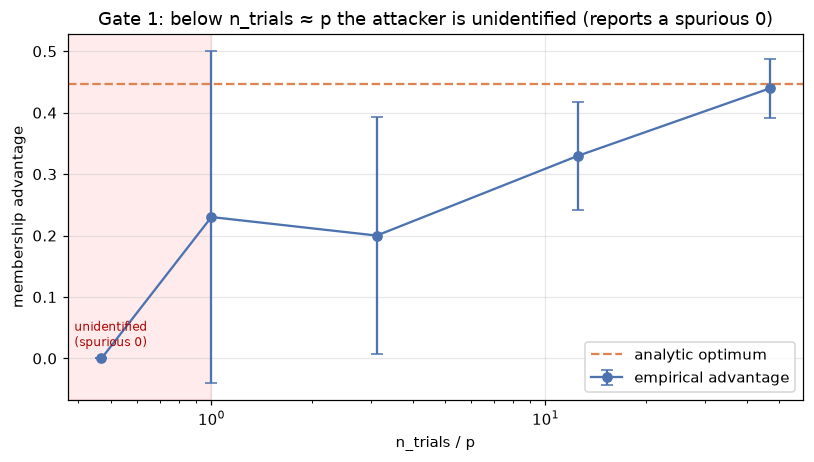

 n_trials  trials_per_p  adv  ci_width  analytic
       30         0.469 0.00     0.000     0.446
       64         1.000 0.23     0.541     0.446
      200         3.125 0.20     0.387     0.446
      800        12.500 0.33     0.176     0.446
     3000        46.875 0.44     0.097     0.446


In [4]:
src64 = make_source((4, 4, 4), N=40)                     # p = 64
npow = patch_power(src64, rel=0.125)                     # data-relative; comparable across datasets
print(f"noise_power = {npow:.4g}  (= 0.125 x patch signal variance)")
rows = []
for nt in [30, 64, 200, 800, 3000]:
    r = ph.evaluate(src64, ph.pipeline_mean, ph.mech_iid, N=40, noise_power=npow,
                    n_trials=nt, n_rel=60, seed=2)
    rows.append((nt, nt/src64.p, r["empirical_adv"], r["adv_ci_hi"]-r["adv_ci_lo"], r["analytic_adv"]))
g1 = pd.DataFrame(rows, columns=["n_trials","trials_per_p","adv","ci_width","analytic"])

fig, ax = plt.subplots(figsize=(7.5, 4.3))
ax.axvspan(0, 1, color="red", alpha=.08); ax.text(0.5, 0.02, "unidentified\n(spurious 0)", ha="center", fontsize=8, color="#a00")
ax.errorbar(g1.trials_per_p, g1.adv, yerr=g1.ci_width/2, fmt="o-", color=PAL["iid"], capsize=4, label="empirical advantage")
ax.axhline(g1.analytic.iloc[0], color=PAL["loo"], ls="--", label="analytic optimum")
ax.set_xscale("log"); ax.set_xlabel("n_trials / p"); ax.set_ylabel("membership advantage")
ax.set_title("Gate 1: below n_trials ≈ p the attacker is unidentified (reports a spurious 0)")
ax.legend(); plt.tight_layout(); plt.show()
print(g1.round(3).to_string(index=False))

## Gate 3 — the rejection-fallback **wall** (the headline)

Two things happen as patches grow. The LOO covariance becomes **rank-deficient** once `p > N−1`. More
importantly, accepting a correlated draw requires it to dominate every subject's influence at **all** `p`
voxels at once — a condition whose probability shrinks fast with `p`, so the mechanism **falls back to
independent noise**. This is a property of Baseline A's rejection rule (which we do not modify) and it is the
dominant high-`p` effect.

[fetch_oasis_vbm] Dataset directory found: /home/luki/nilearn_data/oasis1
[fetch_oasis_vbm] Dataset directory found: /home/luki/nilearn_data/oasis1
[fetch_oasis_vbm] Dataset directory found: /home/luki/nilearn_data/oasis1
[fetch_oasis_vbm] Dataset directory found: /home/luki/nilearn_data/oasis1
[fetch_oasis_vbm] Dataset directory found: /home/luki/nilearn_data/oasis1


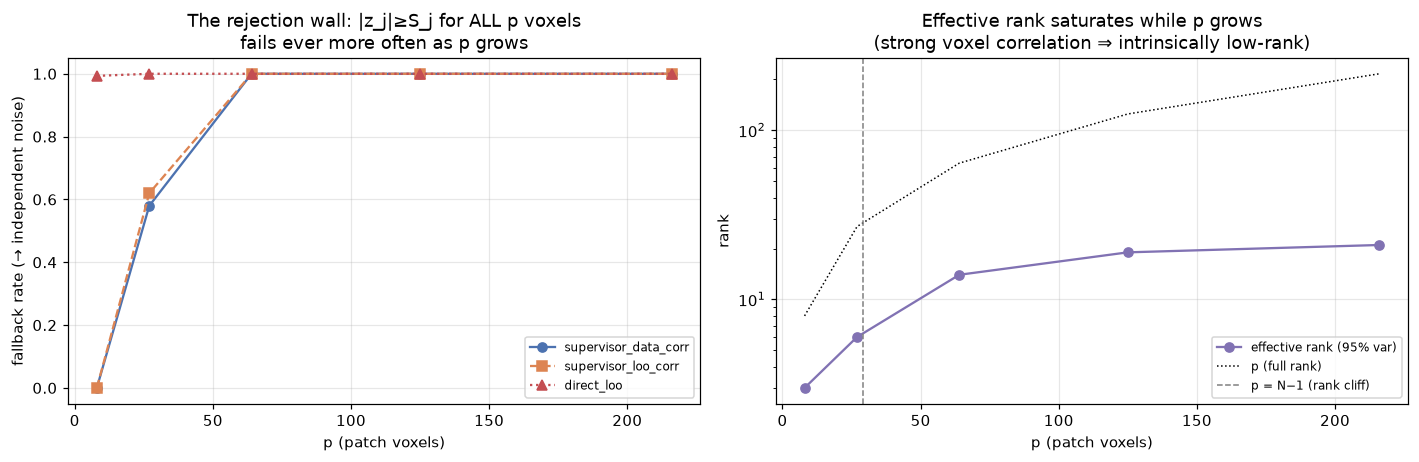

  p  eff_rank  min_eig  fb_data  fb_loo  fb_direct_loo
  8         3      0.0     0.00    0.00          0.993
 27         6      0.0     0.58    0.62          1.000
 64        14     -0.0     1.00    1.00          1.000
125        19     -0.0     1.00    1.00          1.000
216        21     -0.0     1.00    1.00          1.000


In [5]:
rng = np.random.default_rng(0)
rows = []
for bs in [(2,2,2),(3,3,3),(4,4,4),(5,5,5),(6,6,6)]:
    s = make_source(bs, N=30); stack = s.sample(s.N, rng)
    y, D, S = ph.loo_artifacts(stack, ph.pipeline_mean)
    Cloo = np.atleast_2d(np.cov(D.reshape(s.N, -1), rowvar=False))
    fb = {}
    for nm, mech in [("data", ph.mech_supervisor_data_corr()),
                     ("loo", ph.mech_supervisor_loo_corr()),
                     ("direct_loo", ph.mech_direct_loo_cov())]:
        m = mech(y, D, S, subjects=stack)
        for _ in range(150): m.sample(rng)
        fb[nm] = m.fallback_rate
    rows.append((s.p, effective_rank(Cloo), np.linalg.eigvalsh(Cloo).min(), fb["data"], fb["loo"], fb["direct_loo"]))
wall = pd.DataFrame(rows, columns=["p","eff_rank","min_eig","fb_data","fb_loo","fb_direct_loo"])

fig, ax = plt.subplots(1, 2, figsize=(13, 4.3))
ax[0].plot(wall.p, wall.fb_data, "o-", color=PAL["data"], label="supervisor_data_corr")
ax[0].plot(wall.p, wall.fb_loo, "s--", color=PAL["loo"], label="supervisor_loo_corr")
ax[0].plot(wall.p, wall.fb_direct_loo, "^:", color=PAL["direct_loo"], label="direct_loo")
ax[0].set_xlabel("p (patch voxels)"); ax[0].set_ylabel("fallback rate (→ independent noise)")
ax[0].set_title("The rejection wall: |z_j|≥S_j for ALL p voxels\nfails ever more often as p grows"); ax[0].legend(fontsize=8)
ax[1].plot(wall.p, wall.eff_rank, "o-", color="#8172b3", label="effective rank (95% var)")
ax[1].plot(wall.p, wall.p, "k:", lw=1, label="p (full rank)")
ax[1].axvline(29, color="grey", ls="--", lw=1, label="p = N−1 (rank cliff)")
ax[1].set_xlabel("p (patch voxels)"); ax[1].set_ylabel("rank"); ax[1].set_yscale("log")
ax[1].set_title("Effective rank saturates while p grows\n(strong voxel correlation ⇒ intrinsically low-rank)"); ax[1].legend(fontsize=8)
plt.tight_layout(); plt.show()
print(wall.round(3).to_string(index=False))

**Read-off (Gate 3).** Effective rank plateaus (≈ a couple of dozen) while `p` climbs into the hundreds, so
the covariance is intrinsically low-rank. `direct_loo` collapses first — 100% fallback by `p≈27` — because its
raw, rank-deficient covariance cannot pass the rejection rule. The supervisor variants survive small patches
but hit the same wall by `p≈100–200`. **`data` and `loo` fall back identically**, so the covariance-source
choice does not even change mechanism health. The bottleneck at high `p` is the rejection rule, not the source.

## The covariance-source question at high `p`

Now the outcome test itself. **First**, the linear **mean** with all four mechanisms (`iid`, `data`, `loo`,
`direct_loo`) at `p=64`, with fallback surfaced — does `data` vs `loo` finally diverge, and what does
`direct_loo` do? `n_trials ≫ p`, so Gate 1 is satisfied.

[fetch_oasis_vbm] Dataset directory found: /home/luki/nilearn_data/oasis1


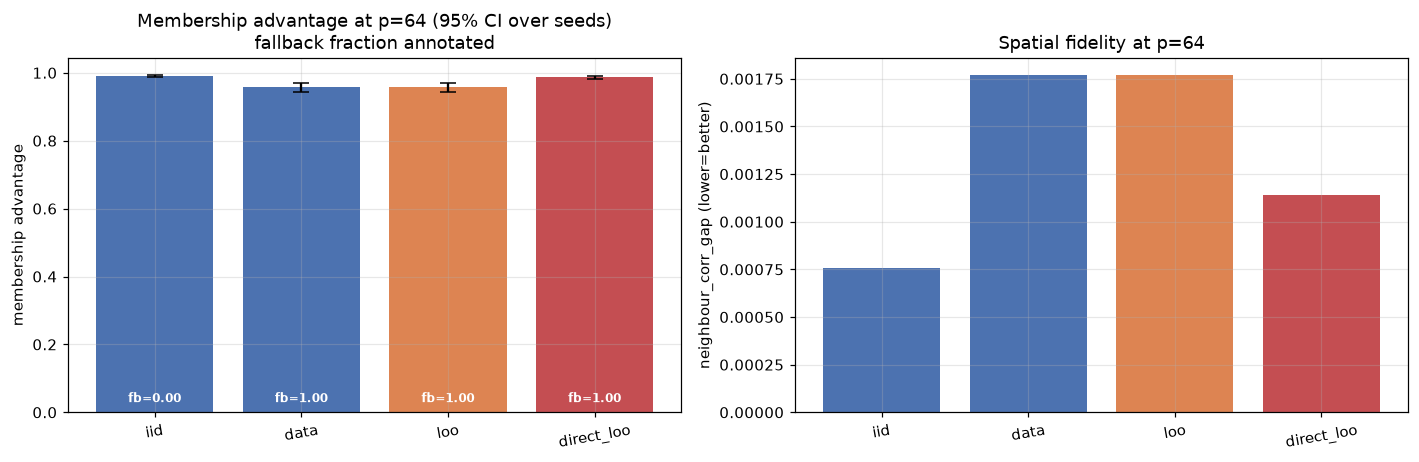

 mechanism  empirical_adv_mean  empirical_adv_lo  empirical_adv_hi  neighbour_corr_gap_mean  fallback_rate_mean
       iid               0.990             0.986             0.994                    0.001                 0.0
      data               0.958             0.945             0.971                    0.002                 1.0
       loo               0.958             0.945             0.971                    0.002                 1.0
direct_loo               0.987             0.983             0.990                    0.001                 1.0


In [6]:
src64 = make_source((4, 4, 4), N=40)   # p = 64
mechs = {"iid": ph.mech_iid,
         "data": ph.mech_supervisor_data_corr(max_draws=300),
         "loo": ph.mech_supervisor_loo_corr(max_draws=300),
         "direct_loo": ph.mech_direct_loo_cov(max_draws=300)}
df = ph.sweep(src64, ph.pipeline_mean, mechs, N_list=[40], power_scales=None,
              seeds=(1, 2, 3), n_trials=1200, n_rel=100)      # n_rel, n_trials > p = 64
agg = ph.aggregate_sweep(df, group_cols=("mechanism",),
                         metrics=("empirical_adv", "neighbour_corr_gap", "fallback_rate"))
order = ["iid", "data", "loo", "direct_loo"]; agg = agg.set_index("mechanism").reindex(order).reset_index()

fig, ax = plt.subplots(1, 2, figsize=(13, 4.3)); x = np.arange(len(order))
yerr = [agg.empirical_adv_mean - agg.empirical_adv_lo, agg.empirical_adv_hi - agg.empirical_adv_mean]
bars = ax[0].bar(x, agg.empirical_adv_mean, yerr=yerr, capsize=5, color=[PAL[m] for m in order])
for xi, fbv in zip(x, agg.fallback_rate_mean):
    ax[0].text(xi, 0.03, f"fb={fbv:.2f}", ha="center", fontsize=8, color="white", weight="bold")
ax[0].set_xticks(x); ax[0].set_xticklabels(order, rotation=10); ax[0].set_ylabel("membership advantage")
ax[0].set_title("Membership advantage at p=64 (95% CI over seeds)\nfallback fraction annotated")
ax[1].bar(x, agg.neighbour_corr_gap_mean, color=[PAL[m] for m in order])
ax[1].set_xticks(x); ax[1].set_xticklabels(order, rotation=10); ax[1].set_ylabel("neighbour_corr_gap (lower=better)")
ax[1].set_title("Spatial fidelity at p=64")
plt.tight_layout(); plt.show()
print(agg[["mechanism","empirical_adv_mean","empirical_adv_lo","empirical_adv_hi",
           "neighbour_corr_gap_mean","fallback_rate_mean"]].round(3).to_string(index=False))

**Read-off (source at high `p`).** `data` and `loo` are indistinguishable on every axis — advantage,
spatial fidelity, and fallback — so the low-dimensional neutrality **persists into high `p`**. `direct_loo`
is not "better covariance", it has simply collapsed to 100% fallback (independent noise), which is why it
leaks like `iid`. The covariance-source question is, at high `p`, **moot for a mechanism reason**: the
rejection rule prevents *any* variant from delivering correlated noise, so there is no structure left for the
source to shape.

### Non-linear statistics — where the source *could* diverge

The mean is the anchor: for a linear statistic `Cov(LOO)` and `Cov(data)` are proportional, so the two sources
are structurally identical. For **non-linear** statistics (median, variance) they need not be — so this is
where the source could finally matter. We look at it two ways: **structurally**, how aligned the two sources'
top noise directions are (subspace overlap: 1 = identical, lower = divergent), and **operationally**, the
membership advantage and fallback for `data` vs `loo`, per statistic.

[fetch_oasis_vbm] Dataset directory found: /home/luki/nilearn_data/oasis1


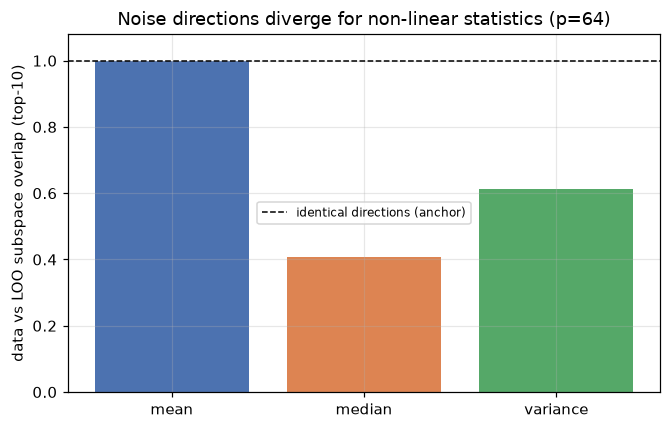

{'mean': 1.0, 'median': 0.407, 'variance': 0.613}


In [7]:
src = make_source((4, 4, 4), N=40)          # p = 64
stack = src.sample(src.N, np.random.default_rng(0))
_, Vdata = eig_cov(stack)
pipes = {"mean": ph.pipeline_mean, "median": ph.pipeline_median, "variance": ph.pipeline_variance}
overlaps = {}
for name, pipe in pipes.items():
    _, D, _ = ph.loo_artifacts(stack, pipe)
    _, Vloo = eig_cov(D.reshape(src.N, -1))
    overlaps[name] = subspace_overlap(Vdata, Vloo, 10)

plt.figure(figsize=(6.2, 4))
plt.bar(list(overlaps), list(overlaps.values()), color=[PAL[n] for n in overlaps])
plt.axhline(1.0, color="k", ls="--", lw=1, label="identical directions (anchor)")
plt.ylabel("data vs LOO subspace overlap (top-10)"); plt.ylim(0, 1.08)
plt.title(f"Noise directions diverge for non-linear statistics (p={src.p})")
plt.legend(fontsize=8); plt.tight_layout(); plt.show()
print({k: round(v, 3) for k, v in overlaps.items()})

[fetch_oasis_vbm] Dataset directory found: /home/luki/nilearn_data/oasis1


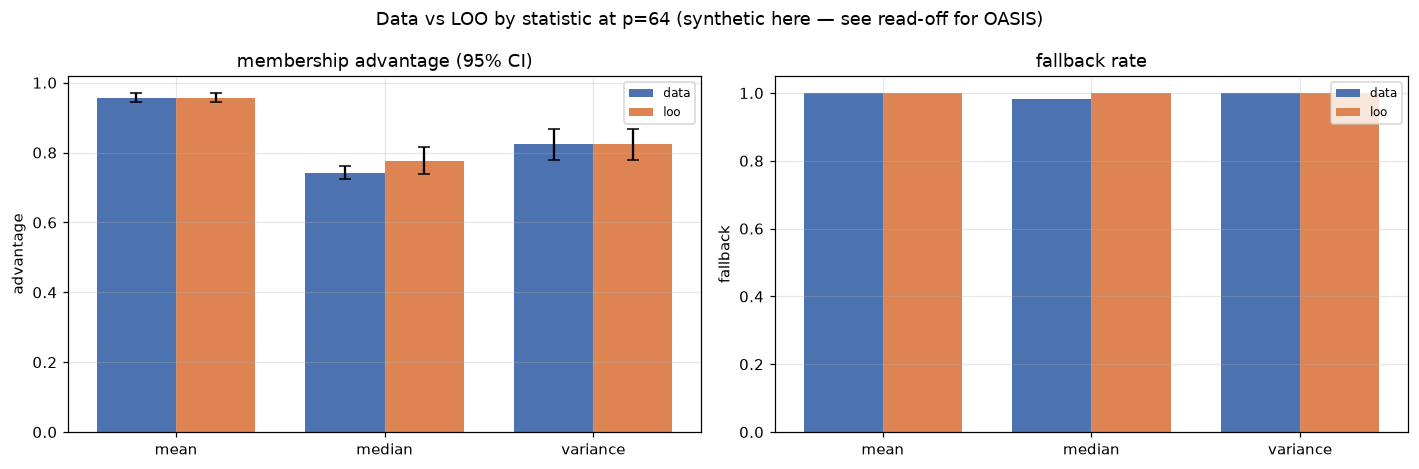

    stat mech   adv    lo    hi    fb
    mean data 0.958 0.945 0.971 1.000
    mean  loo 0.958 0.945 0.971 1.000
  median data 0.742 0.724 0.761 0.982
  median  loo 0.777 0.738 0.817 1.000
variance data 0.824 0.780 0.867 1.000
variance  loo 0.824 0.780 0.867 1.000


In [8]:
src = make_source((4, 4, 4), N=40)
mechs = {"data": ph.mech_supervisor_data_corr(max_draws=300),
         "loo":  ph.mech_supervisor_loo_corr(max_draws=300)}
rows = []
for pname, pipe in pipes.items():
    df = ph.sweep(src, pipe, mechs, N_list=[40], power_scales=None, seeds=(1, 2, 3), n_trials=1200, n_rel=100)
    agg = ph.aggregate_sweep(df, group_cols=("mechanism",), metrics=("empirical_adv", "fallback_rate"))
    for _, r in agg.iterrows():
        rows.append((pname, r["mechanism"], r["empirical_adv_mean"], r["empirical_adv_lo"],
                     r["empirical_adv_hi"], r["fallback_rate_mean"]))
op = pd.DataFrame(rows, columns=["stat","mech","adv","lo","hi","fb"])

fig, ax = plt.subplots(1, 2, figsize=(13, 4.3)); x = np.arange(len(pipes)); w = 0.38
for i, m in enumerate(["data", "loo"]):
    s = op[op.mech == m].set_index("stat").reindex(list(pipes))
    ax[0].bar(x+(i-0.5)*w, s.adv, w, yerr=[s.adv-s.lo, s.hi-s.adv], capsize=4,
              color=PAL[m], label=f"{m}")
    ax[1].bar(x+(i-0.5)*w, s.fb, w, color=PAL[m], label=f"{m}")
for a, t, yl in [(ax[0], "membership advantage (95% CI)", "advantage"), (ax[1], "fallback rate", "fallback")]:
    a.set_xticks(x); a.set_xticklabels(list(pipes)); a.set_title(t); a.set_ylabel(yl); a.legend(fontsize=8)
plt.suptitle("Data vs LOO by statistic at p=64 (synthetic here — see read-off for OASIS)"); plt.tight_layout(); plt.show()
print(op.round(3).to_string(index=False))

**Read-off (non-linear).** *Structurally*, the mean's two sources are identical (overlap ≈ 1, the anchor)
while the median and variance diverge (overlap well below 1) — so the source **is** a real structural choice
for non-linear statistics at high `p`. *Operationally*, though, the honest picture depends on the data. On the
**synthetic** substrate shown here the median shows a striking fallback divergence (`data` clears the bars,
`loo` falls back much more). **On real OASIS this washes out**: at `p=64` OASIS is smoother and lower-rank, so
*both* sources hit ~100% fallback for the median and the divergence disappears — the wall swallows it. So the
source is structurally different for non-linear statistics but, on real data at this patch size, operationally
neutral because nothing survives the wall. (Re-run with `USE_OASIS = True` to reproduce the washout.)

## Gate 2 — mass-univariate inference with multiple-comparisons control

Per-voxel one-sample t-tests over `p` voxels are a multiple-comparisons problem: uncorrected family-wise error
(the chance of *any* false positive) rushes to 1 as `p` grows. We apply **Bonferroni** and **Holm** (control
FWER) and **Benjamini–Hochberg** (controls the false discovery rate), and ask whether privatization changes the
corrected error and power.

In [9]:
def _bh(pvals, q):                                   # Benjamini-Hochberg FDR
    p = np.asarray(pvals); m = len(p); o = np.argsort(p); passed = p[o] <= q*np.arange(1, m+1)/m
    rej = np.zeros(m, bool)
    if passed.any(): rej[o[:np.max(np.where(passed)[0])+1]] = True
    return rej
def _holm(pvals, a):                                 # Holm FWER
    p = np.asarray(pvals); m = len(p); rej = np.zeros(m, bool)
    for i, idx in enumerate(np.argsort(p)):
        if p[idx] <= a/(m-i): rej[idx] = True
        else: break
    return rej

def mass_univariate(mech, src, n=40, frac_active=0.25, effect=0.8, mc=120, alpha=0.05, seed=0):
    "Per-voxel one-sample t over correlated voxels; report the error each method controls + power, clean vs private."
    rng = np.random.default_rng(seed); p = src.p
    L = np.linalg.cholesky(np.atleast_2d(src.Sigma_x) + 1e-9*np.eye(p)) if hasattr(src, "Sigma_x") \
        else np.linalg.cholesky(np.cov(src.sample(200, rng), rowvar=False) + 1e-9*np.eye(p))
    active = np.zeros(p, bool); active[rng.choice(p, int(frac_active*p), replace=False)] = True
    mu = np.where(active, effect, 0.0)
    def stat(d): return d.mean(0) / (d.std(0, ddof=1) / np.sqrt(len(d)))
    acc = {k: {"fwer_c":0,"fwer_p":0,"fdp_c":[],"fdp_p":[],"pow_c":[],"pow_p":[]}
           for k in ["uncorrected","bonferroni","holm","BH"]}
    for _ in range(mc):
        data = mu + rng.standard_normal((n, p)) @ L.T
        y, D, S = ph.loo_artifacts(data, stat); noised = y + mech(y, D, S, subjects=data).sample(rng)
        for tag, tv in [("c", y), ("p", noised)]:
            pv = 2*tdist.sf(np.abs(tv), df=n-1)
            rejs = {"uncorrected": pv < alpha, "bonferroni": pv < alpha/p, "holm": _holm(pv, alpha), "BH": _bh(pv, alpha)}
            for k, rej in rejs.items():
                fp = rej[~active].any(); nrej = rej.sum()
                acc[k]["fwer_"+tag] += int(fp)
                acc[k]["fdp_"+tag].append(rej[~active].sum()/nrej if nrej else 0.0)
                acc[k]["pow_"+tag].append(rej[active].mean())
    out = []
    for k, a in acc.items():
        out.append({"correction": k, "controls": "FDR" if k=="BH" else ("—" if k=="uncorrected" else "FWER"),
                    "FWER_clean": a["fwer_c"]/mc, "FWER_priv": a["fwer_p"]/mc,
                    "FDR_clean": np.mean(a["fdp_c"]), "FDR_priv": np.mean(a["fdp_p"]),
                    "power_clean": np.mean(a["pow_c"]), "power_priv": np.mean(a["pow_p"])})
    return pd.DataFrame(out)

src64 = make_source((4, 4, 4), N=40)
mu_tab = mass_univariate(ph.mech_supervisor_data_corr(max_draws=200), src64, mc=120, seed=1)
print("data mechanism (loo is identical):")
print(mu_tab.round(3).to_string(index=False))

[fetch_oasis_vbm] Dataset directory found: /home/luki/nilearn_data/oasis1
data mechanism (loo is identical):
 correction controls  FWER_clean  FWER_priv  FDR_clean  FDR_priv  power_clean  power_priv
uncorrected        —       0.667      0.867      0.113     0.184          1.0         1.0
 bonferroni     FWER       0.017      0.050      0.001     0.004          1.0         1.0
       holm     FWER       0.025      0.067      0.002     0.006          1.0         1.0
         BH      FDR       0.292      0.592      0.031     0.084          1.0         1.0


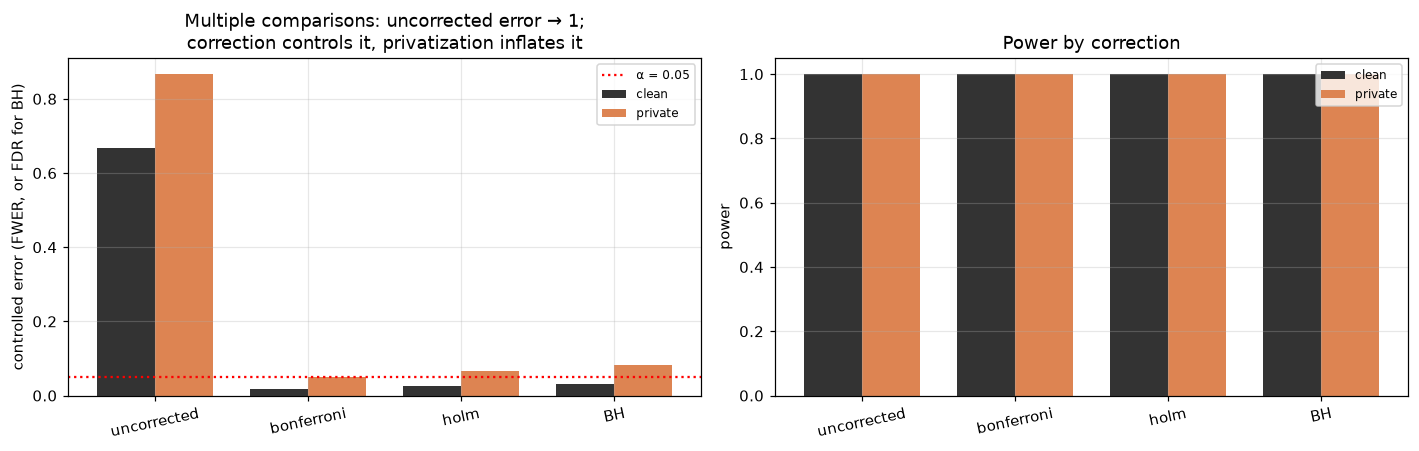

In [10]:
# The controlled-error and power picture, clean vs private
meth = mu_tab.correction.tolist(); x = np.arange(len(meth)); w = 0.38
err_c = [row.FDR_clean if row.controls=="FDR" else row.FWER_clean for row in mu_tab.itertuples()]
err_p = [row.FDR_priv  if row.controls=="FDR" else row.FWER_priv  for row in mu_tab.itertuples()]
fig, ax = plt.subplots(1, 2, figsize=(13, 4.2))
ax[0].bar(x-w/2, err_c, w, label="clean", color=PAL["clean"])
ax[0].bar(x+w/2, err_p, w, label="private", color=PAL["loo"])
ax[0].axhline(0.05, color="r", ls=":", label="α = 0.05")
ax[0].set_xticks(x); ax[0].set_xticklabels(meth, rotation=12); ax[0].set_ylabel("controlled error (FWER, or FDR for BH)")
ax[0].set_title("Multiple comparisons: uncorrected error → 1;\ncorrection controls it, privatization inflates it"); ax[0].legend(fontsize=8)
ax[1].bar(x-w/2, mu_tab.power_clean, w, label="clean", color=PAL["clean"])
ax[1].bar(x+w/2, mu_tab.power_priv, w, label="private", color=PAL["loo"])
ax[1].set_xticks(x); ax[1].set_xticklabels(meth, rotation=12); ax[1].set_ylabel("power"); ax[1].set_title("Power by correction")
ax[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

**Read-off (Gate 2).** Uncorrected FWER is ≈1 at `p=64` — correction is mandatory. Bonferroni/Holm restore
control on the *clean* test, but **privatization inflates the corrected error** (the small-`N` rejection-rule
Type-I inflation now compounds with the multiple-comparisons burden); BH keeps more power at a higher (FDR)
error budget. `data` and `loo` give identical tables. Any high-`p` inference claim must state its correction
*and* account for privatization's extra inflation.

## Validation — the analytic oracle at high `p`

Where the mechanism is exactly Gaussian with a world-independent covariance (`mech_iid`), the analytic
Mahalanobis advantage is exact and validates the empirical attacker. We check it at a few noise levels chosen
(via `patch_power`) to land in a detectable mid-range, so the match is actually visible.

In [11]:
src64 = make_source((4, 4, 4), N=40)
for rel in [0.05, 0.15, 0.5]:                            # smaller rel = less noise = higher advantage
    npow = patch_power(src64, rel=rel)
    r = ph.evaluate(src64, ph.pipeline_mean, ph.mech_iid, N=40, noise_power=npow,
                    n_trials=4000, n_rel=30, seed=5)
    print(f"rel={rel:>4}  noise_power={npow:8.4g}: empirical={r['empirical_adv']:.3f} "
          f"[{r['adv_ci_lo']:.3f},{r['adv_ci_hi']:.3f}]  analytic={r['analytic_adv']:.3f}  (p={src64.p})")

[fetch_oasis_vbm] Dataset directory found: /home/luki/nilearn_data/oasis1
rel=0.05  noise_power= 0.02383: empirical=0.606 [0.565,0.637]  analytic=0.622  (p=64)
rel=0.15  noise_power= 0.07149: empirical=0.349 [0.310,0.380]  analytic=0.389  (p=64)
rel= 0.5  noise_power=  0.2383: empirical=0.205 [0.165,0.246]  analytic=0.219  (p=64)


## Conclusions — what the imaging phase establishes

- **The four gates are real and enforced.** Trials must exceed `p` (else a spurious-0 advantage); mass-univariate
  inference needs FWER/FDR control; the LOO covariance is intrinsically **low-rank** (effective rank plateaus
  while `p` grows); every run is screened with `cov_diagnostics`.
- **The high-`p` bottleneck is the mechanism's rejection rule, not the covariance source.** Requiring the noise
  to dominate influence at all `p` voxels forces fallback to independent noise — `direct_loo` first, the
  supervisor variants by `p≈100–200`, and on OASIS essentially everything by `p=64`.
- **`data` ≈ `loo`.** For the linear mean they are structurally identical (the anchor). For **non-linear**
  statistics they diverge *structurally* (subspace overlap well below 1), but on real OASIS that divergence is
  *operationally* erased by the wall — both fall back near-fully. So the covariance source is not, on real data
  at this patch size, a lever on privacy; the wall is.
- Privatization inflates corrected Type-I error at small `N`, compounding with multiple comparisons.

**Where next.** The wall — not the source — is the thing to fix, and whether it can be fixed is taken up in
notebook 6.2 (low-rank feasibility). Notebook 6.1 characterizes *how* low-rank the noise is; notebook 6.3 sizes
the patches. *No DP guarantees; advantage is a lower bound on leakage, compared between mechanisms.*